# Предсказание октановых чисел (RON/MON) методами машинного обучения

## Содержание

1. **Введение** -- RON, MON и их значение в нефтехимии
2. **Загрузка и разведочный анализ данных (EDA)**
3. **Построение молекулярных дескрипторов с RDKit**
4. **Отбор признаков (Feature Selection)**
5. **Обучение моделей** -- базовые модели и CatBoost
6. **Логирование экспериментов с MLflow**
7. **Конфигурация пайплайна с Hydra**
8. **Подбор гиперпараметров с Optuna**
9. **Итоговый пайплайн и выводы**

## 1. Введение

**RON** (Research Octane Number) и **MON** (Motor Octane Number) -- ключевые характеристики топлива, определяющие его детонационную стойкость.

- **RON** измеряется при стандартных условиях (600 об/мин)
- **MON** измеряется при более жестких условиях (900 об/мин, предварительный подогрев)
- **OS** (Octane Sensitivity) = RON - MON

Задача: по структуре молекулы (SMILES) предсказать RON и MON, используя молекулярные дескрипторы.

## 2. Загрузка и разведочный анализ данных (EDA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

df = pd.read_csv("data.csv", encoding="utf-8-sig")
print(f"Dataset: {df.shape[0]} compounds, {df.shape[1]} columns")
df.head(10)

Dataset: 260 compounds, 26 columns


,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
5,n-Heptane,Alkanes,CCCCCCCC,2,5,0,0,0,0,0,...,0.0,0,0,0,0,0,0,0.0,0.0,0.0
6,2-Methylpropane,Alkanes,CC(C)C,3,0,1,0,0,0,0,...,1.0,0,0,0,0,0,0,102.1,97.6,4.5
7,2-Methylbutane,Alkanes,CCC(C)C,3,1,1,0,0,0,0,...,1.0,0,0,0,0,0,0,92.3,90.3,2.0
8,2_2-Dimethylpropane,Alkanes,CC(C)(C)C,4,0,0,1,0,0,0,...,2.0,0,0,0,0,0,0,85.5,80.2,5.3
9,2-Methylpentane,Alkanes,CCCC(C)C,3,2,1,0,0,0,0,...,1.0,0,0,0,0,0,0,73.4,73.5,-0.1


In [2]:
df

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,Furan,Other_oxygenates,O1C=CC=C1,0,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,108.6,91.6,17.0
256,2-Methylfuran,Other_oxygenates,CC1=CC=CO1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,102.5,86.1,16.4
257,2_5-Dimethylfuran,Other_oxygenates,CC1=CC=C(C)O1,2,0,0,0,0,0,0,...,0.0,0,1,0,1,0,0,101.3,88.1,13.2
258,Anisole,Other_oxygenates,COC1=CC=CC=C1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,103.0,92.0,11.0


In [3]:
# Проверим пропуски
missing = df.isnull().sum()
print("Пропущенные значения:")
print(missing[missing > 0])

# Удалим строки без целевой переменной RON
df_clean = df.dropna(subset=["RON", "MON"]).copy()
print(f"\nПосле удаления пропусков: {len(df_clean)} соединений")

Пропущенные значения:
RON     4
MON     7
OS     11
dtype: int64

После удаления пропусков: 249 соединений


In [4]:
df_clean

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,Furan,Other_oxygenates,O1C=CC=C1,0,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,108.6,91.6,17.0
256,2-Methylfuran,Other_oxygenates,CC1=CC=CO1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,102.5,86.1,16.4
257,2_5-Dimethylfuran,Other_oxygenates,CC1=CC=C(C)O1,2,0,0,0,0,0,0,...,0.0,0,1,0,1,0,0,101.3,88.1,13.2
258,Anisole,Other_oxygenates,COC1=CC=CC=C1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,103.0,92.0,11.0


### Задание 1: Визуализация распределений

Постройте 3 графика в одном ряду (`plt.subplots(1, 3, ...)`):
1. Барплот количества соединений по `FuelClass`
2. Гистограмма распределения `RON` с вертикальной линией среднего
3. Гистограмма распределения `MON` с вертикальной линией среднего

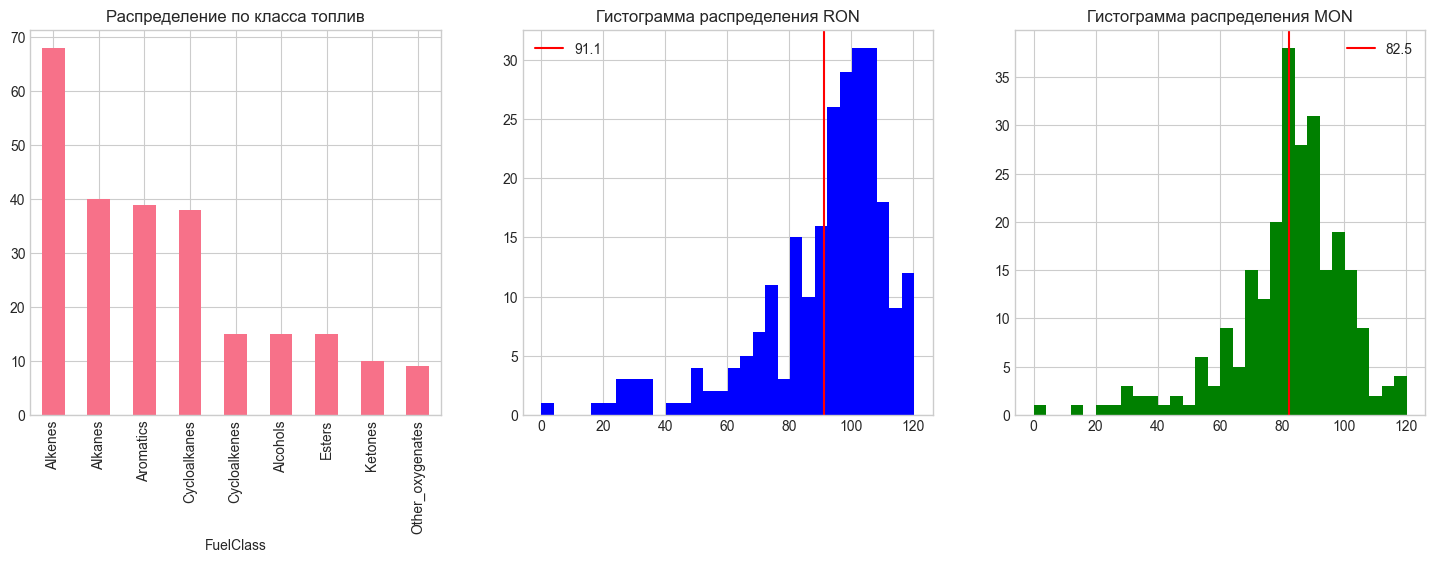

In [24]:
# YOUR CODE HERE
fig, axes = plt.subplots(1,3,figsize=(18,5))

df_clean["FuelClass"].value_counts().plot.bar(ax=axes[0])
axes[0].set_title("Распределение по класса топлив")
axes[1].hist(df_clean["RON"], bins=30, color="blue")
axes[1].axvline(df_clean["RON"].mean(), color="red", label= f"{df_clean["RON"].mean():.1f}")
axes[1].set_title("Гистограмма распределения RON")
axes[1].legend()

axes[2].hist(df_clean["MON"], bins=30, color="green")
axes[2].axvline(df_clean["MON"].mean(), color="red", label= f"{df_clean["MON"].mean():.1f}")
axes[2].set_title("Гистограмма распределения MON")
axes[2].legend()

### Задание 2: RON vs MON

Постройте scatter plot RON vs MON, раскрашенный по `FuelClass`.
Добавьте диагональную линию RON = MON для наглядности.

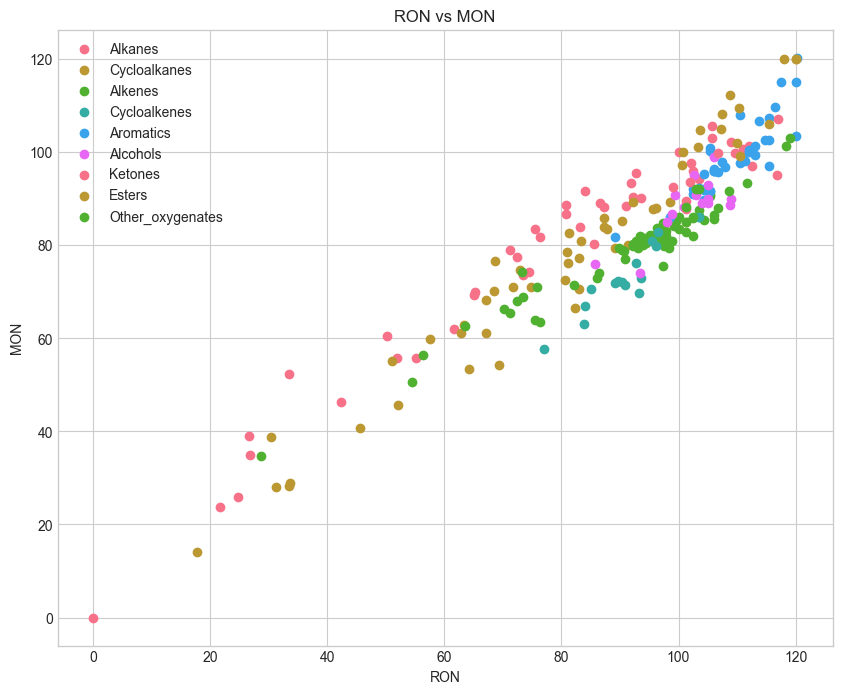

In [27]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10,8))
for f_c in df_clean["FuelClass"].unique():
    subset = df_clean[df_clean["FuelClass"] == f_c]
    ax.scatter(subset["RON"], subset["MON"], label=f_c)

ax.set_xlabel("RON")
ax.set_ylabel("MON")
ax.set_title("RON vs MON")
ax.legend()
plt.show()

### Задание 3: Boxplot по классам

Постройте boxplot RON и MON по классам топлив (отсортируйте по медиане RON).

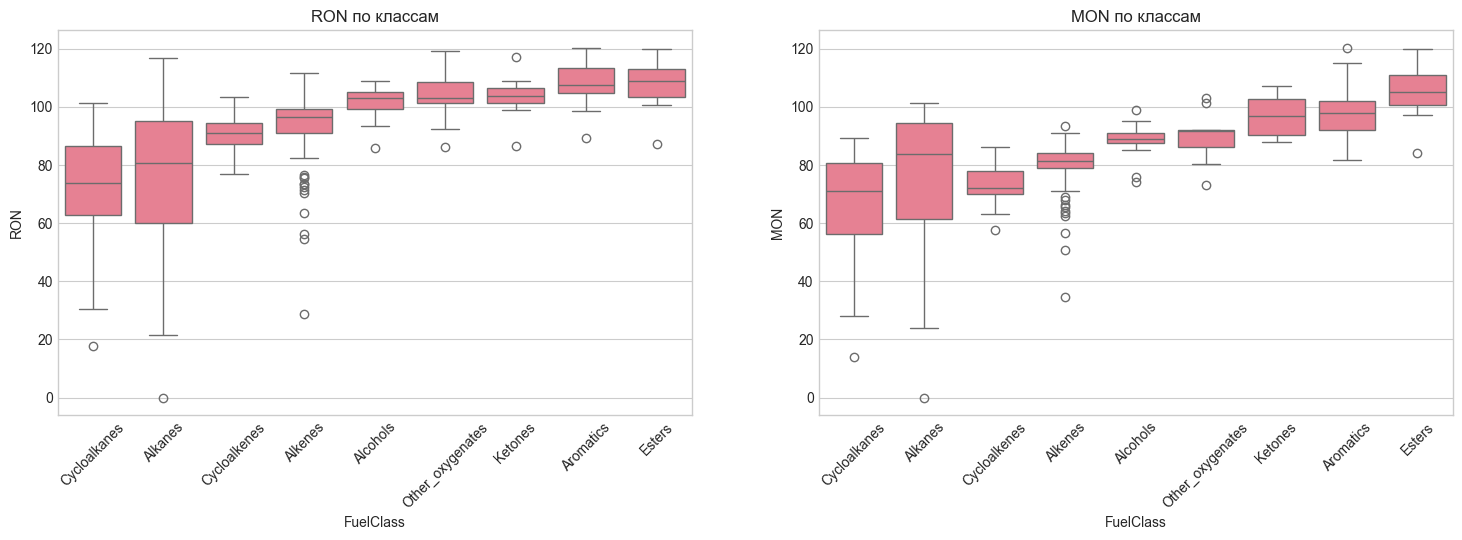

In [35]:
# YOUR CODE HERE
fig, axes = plt.subplots(1,2,figsize=(18,5))

order = df_clean.groupby("FuelClass")["RON"].median().sort_values().index

sns.boxplot(data=df_clean, x="FuelClass", y="RON", order=order, ax=axes[0])
axes[0].set_title("RON по классам")
axes[0].tick_params(axis= "x", rotation=45)

sns.boxplot(data=df_clean, x="FuelClass", y="MON", order=order, ax=axes[1])
axes[1].set_title("MON по классам")
axes[1].tick_params(axis= "x", rotation=45)

plt.show()

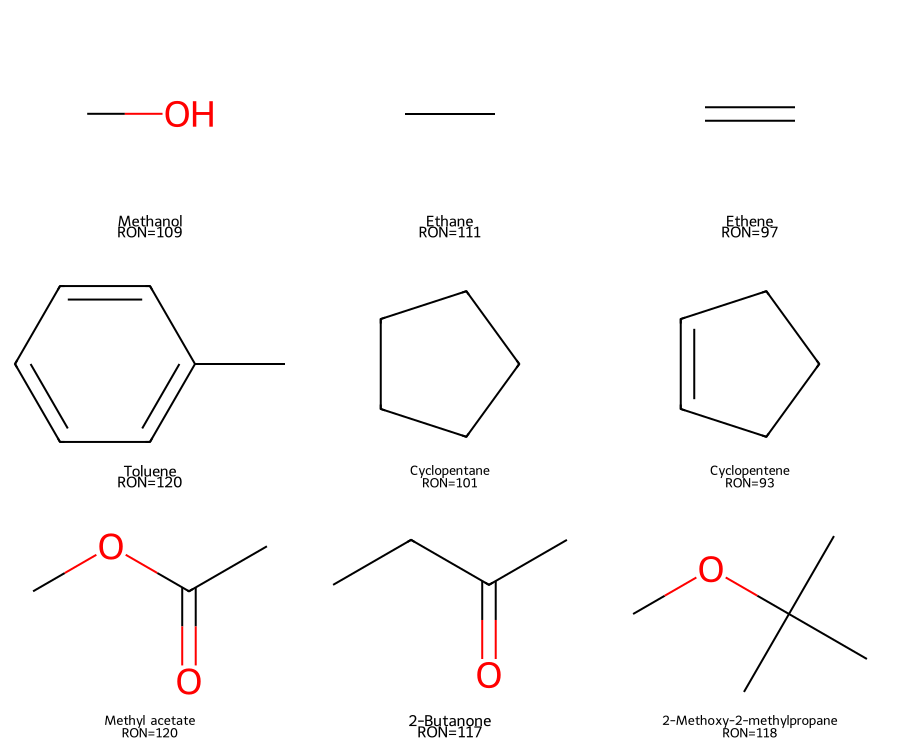

In [36]:
# Визуализация молекул из разных классов
samples = df_clean.groupby("FuelClass").first().reset_index()
mols = [Chem.MolFromSmiles(s) for s in samples["Smiles"]]
legends = [f"{row['Name']}\nRON={row['RON']:.0f}" for _, row in samples.iterrows()]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 250), legends=legends)
img

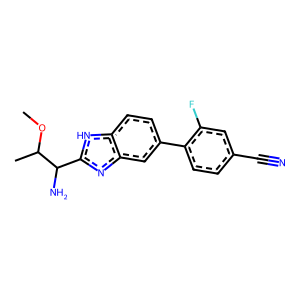

In [64]:
from IPython.display import display, SVG
smiles = "COC(C)C(N)c1nc2cc(-c3ccc(C#N)cc3F)ccc2[nH]1" 

mol = Chem.MolFromSmiles(smiles)
mol_kek = Chem.Mol(mol)
#Chem.Kekulize(mol_kek, clearAromaticFlags=True)
img = Draw.MolToImage(mol_kek, kekulize=False)
img

## 3. Построение молекулярных дескрипторов с RDKit

### Подходы к описанию молекул:

| Тип дескриптора | Описание | Пример |
|:---|:---|:---|
| **2D дескрипторы** | Физико-химические свойства | MolWt, LogP, TPSA, HBA/HBD |
| **Фингерпринты** | Бинарное представление субструктур | Morgan (ECFP), MACCS, RDKit FP |
| **3D дескрипторы** | Геометрия молекулы | Asphericity, Eccentricity |
| **Graph-based** | GNN на молекулярном графе | GCN, MPNN, AttentiveFP |

### Задание 4: Вычисление 2D дескрипторов

Реализуйте функцию `compute_rdkit_2d_descriptors(smiles_list)`, которая:
- Принимает список SMILES
- Для каждого SMILES создает `Chem.MolFromSmiles(smi)` и вычисляет дескрипторы через `Descriptors`
- Возвращает `pd.DataFrame`

Используйте дескрипторы: `MolWt`, `MolLogP`, `TPSA`, `NumHAcceptors`, `NumHDonors`, `NumRotatableBonds`,
`NumAromaticRings`, `NumAliphaticRings`, `RingCount`, `FractionCSP3`, `HeavyAtomCount` и другие на ваш выбор.

Подсказка: `getattr(Descriptors, name)` возвращает функцию-дескриптор.

In [86]:
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


def compute_rdkit_2d_descriptors(smiles_list: list[str]) -> pd.DataFrame:
    desc_names = [
        "MolWt", "MolLogP", "TPSA", "NumHAcceptors", "NumHDonors", "NumRotatableBonds",
        "NumAromaticRings", "NumAliphaticRings", "RingCount", "FractionCSP3", "HeavyAtomCount"
    ]
    desc_func = {name: getattr(Descriptors, name) for name in desc_names if hasattr(Descriptors, name)}
    records = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        records.append({name: func(mol) for name, func in desc_func.items()})
        
    return pd.DataFrame(records)

def comp_fingerprints(smiles_list: list[str], radius: int = 2, n_bits: int = 1024) -> pd.DataFrame:
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        fps.append(gen.GetFingerprintAsNumPy(mol))
    
    cols = [f"morgan_{i}" for i in range(n_bits)]
    return pd.DataFrame(fps, columns=cols)

def comp_maccs_keys(smiles_list: list[str]) -> pd.DataFrame:
    fps = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
        arr = np.zeros(167, dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)
    
    cols = [f"maccs_{i}" for i in range(167)]
    return pd.DataFrame(fps, columns=cols)


In [87]:
smiles = df_clean["Smiles"].tolist()

desc_2d = compute_rdkit_2d_descriptors(smiles)
morgan = comp_fingerprints(smiles)
maccs = comp_maccs_keys(smiles)
df_all = pd.concat([df_clean, desc_2d, morgan, maccs], axis=1)

df_all

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,Ethane,Alkanes,CC,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Propane,Alkanes,CCC,2.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,n-Butane,Alkanes,CCCC,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,n-Pentane,Alkanes,CCCCC,2.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,n-Hexane,Alkanes,CCCCCC,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### Задание 7: Вычислите дескрипторы и объедините

Вызовите все три функции для `df_clean["Smiles"]` и объедините результаты 2D + Morgan через `pd.concat`.

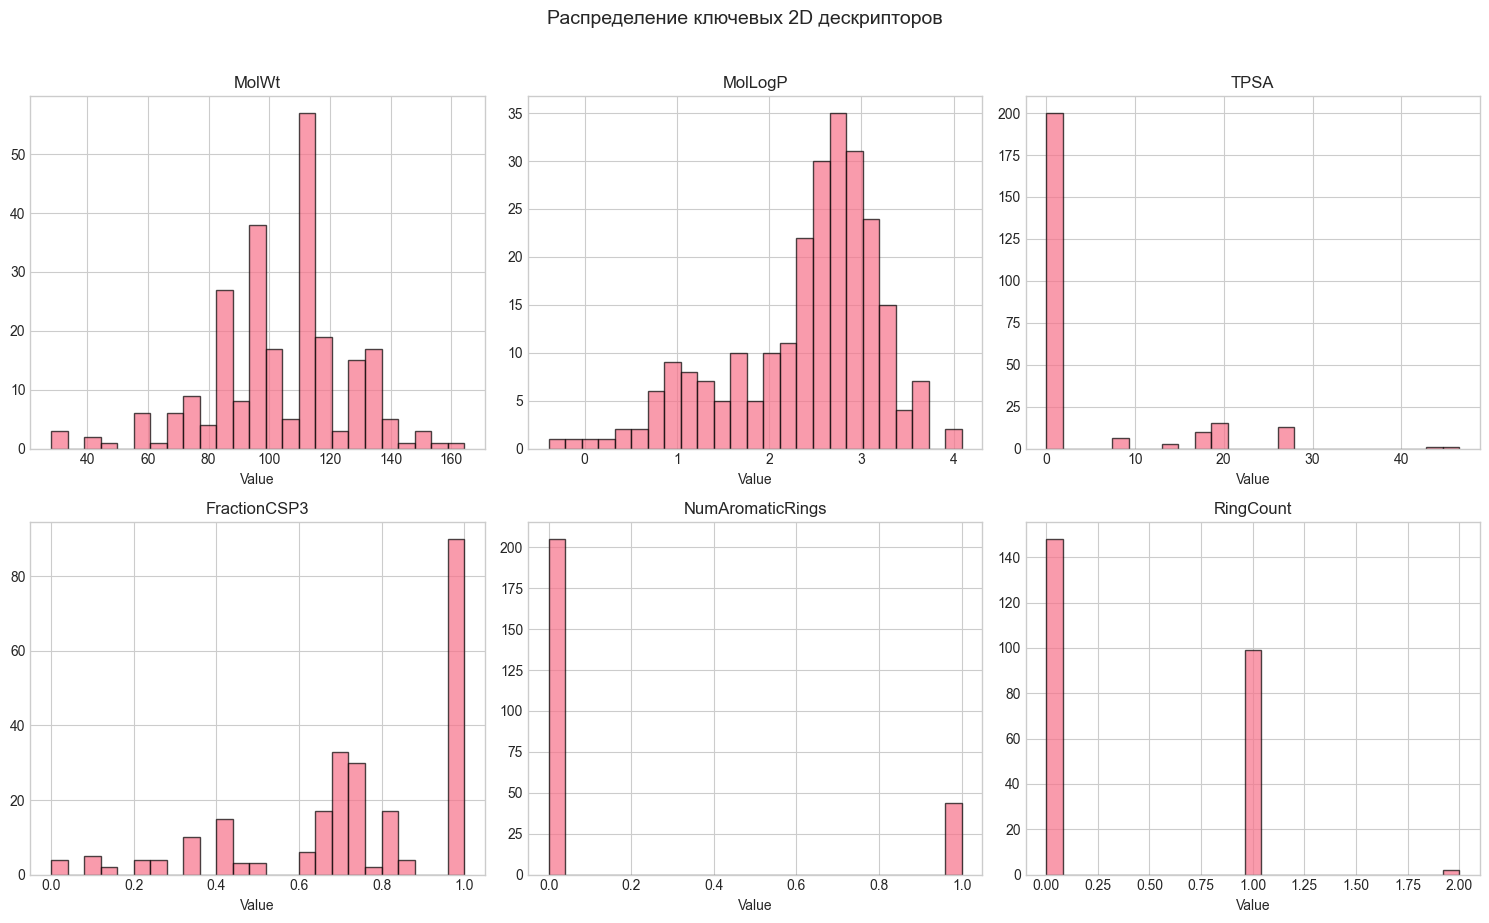

In [88]:
# Посмотрим на распределение нескольких ключевых дескрипторов
key_descriptors = ["MolWt", "MolLogP", "TPSA", "FractionCSP3", "NumAromaticRings", "RingCount"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, desc in zip(axes.flatten(), key_descriptors):
    ax.hist(desc_2d[desc].dropna(), bins=25, edgecolor="black", alpha=0.7)
    ax.set_title(desc)
    ax.set_xlabel("Value")

plt.suptitle("Распределение ключевых 2D дескрипторов", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Задание 8: Корреляция дескрипторов с целевыми переменными

Вычислите корреляцию Пирсона 2D-дескрипторов с RON и MON.
Постройте два горизонтальных барплота (`.plot.barh()`).

Подсказка: `desc_2d.corrwith(pd.Series(y_ron))`

<Axes: >

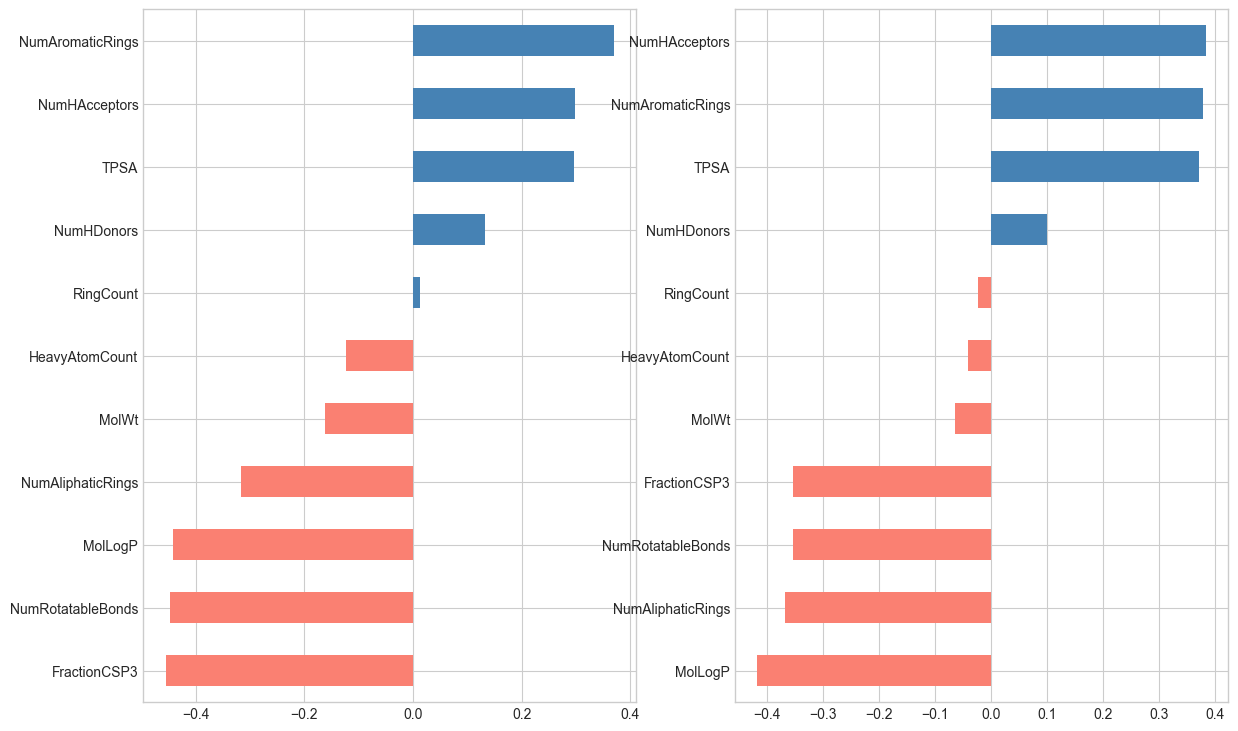

In [96]:
y_ron = df_clean["RON"].values
y_mon = df_clean["MON"].values

# YOUR CODE HERE
corr_ron = desc_2d.corrwith(pd.Series(y_ron)).sort_values()
corr_mon = desc_2d.corrwith(pd.Series(y_mon)).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

corr_ron.plot.barh(ax = axes[0], color = ["steelblue" if v >0 else "salmon" for v in corr_ron])

corr_mon.plot.barh(ax = axes[1], color = ["steelblue" if v >0 else "salmon" for v in corr_mon])

## 4. Отбор признаков (Feature Selection)

При большом числе дескрипторов (особенно фингерпринтов) необходимо:

1. **Удалить константные/низковариативные** признаки
2. **Удалить сильно коррелированные** признаки (мультиколлинеарность)
3. **Отобрать наиболее информативные** признаки (mutual information, importance)

### Задание 9: Реализуйте функции отбора признаков

Реализуйте три функции:

1. `remove_low_variance(X, threshold)` -- используйте `VarianceThreshold` из sklearn
2. `remove_correlated(X, threshold)` -- удалите один из пары признаков с корреляцией > threshold
3. `select_by_mutual_info(X, y, n_features)` -- отберите top-N по `mutual_info_regression`

In [99]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression


def remove_low_variance(X: pd.DataFrame, threshold: float = 0.01) -> pd.DataFrame:
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    mask = selector.get_support()
    X_filtr = X.loc[:,mask]
    return X_filtr


def remove_correlated(X: pd.DataFrame, threshold: float = 0.95) -> pd.DataFrame:
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    X_filtr = X.drop(columns=to_drop)
    return X_filtr


def select_by_mutual_info(
    X: pd.DataFrame, y: np.ndarray, n_features: int = 50
) -> pd.DataFrame:
    scores = mutual_info_regression(X,y, random_state=2026)
    series = pd.Series(scores, index=X.columns).sort_values()
    top_f = series.head(n_features).index.tolist()
    print(len(top_f))
    
    fig, ax = plt.subplots(figsize=(10,6))
    series.head(20).plot.barh(ax=ax, color="teal")
    ax.set_title("Top 20")
    plt.show()
    
    return X[top_f]



In [105]:
df_all

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,Ethane,Alkanes,CC,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Propane,Alkanes,CCC,2.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,n-Butane,Alkanes,CCCC,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,n-Pentane,Alkanes,CCCCC,2.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,n-Hexane,Alkanes,CCCCCC,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### Задание 10: Примените пайплайн отбора признаков

Последовательно примените: `remove_low_variance` -> `remove_correlated` -> `select_by_mutual_info`.

9


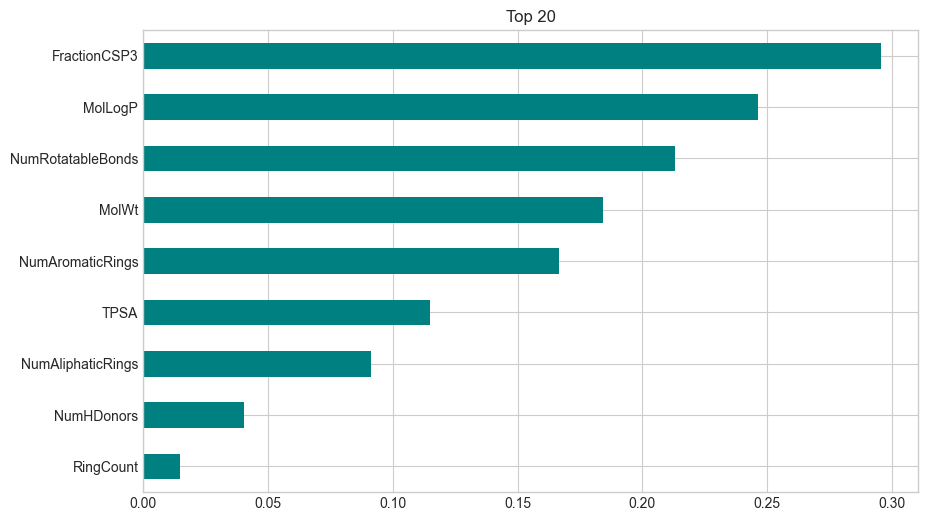

In [108]:
#X_all = df_all.drop(columns=["RON", "MON", "Name", "FuelClass", "Smiles"])

X_all_filled = desc_2d.fillna(0)


X_var = remove_low_variance(X_all_filled)
X_cor = remove_correlated(X_var)
X_selected = select_by_mutual_info(X_cor, y_ron, n_features=50)


array([100.7,  97.1,  90.1,  61.9,  26. ,   0. ,  97.6,  90.3,  80.2,
        73.5,  74.3,  93.4,  94.3,  46.4,  55.8,  95.6,  86.6,  88.5,
        83.8,  69.3, 101.3,  23.8,  35. ,  39. ,  78.9,  69.9,  55.7,
        83.4,  77.4,  81.7,  52.4,  99.9, 100. ,  99.4,  95.9,  88.1,
        88.7,  60.5,  95. ,  91.6,  85. ,  80. ,  72.6,  89.3,  83.5,
        79.5,  88. ,  28.2,  54.3,  66.6,  45.6,  76.2,  28.1,  61.2,
        59.8,  77.2,  71.1,  40.8,  85.9,  78.6,  71. ,  68.2,  87.7,
        82.6,  81. ,  74.6,  70.1,  14. ,  61.1,  76.7,  28.9,  55.2,
        89.2,  38.8,  62.9,  85.1,  53.4,  70.6,  75.6,  84.9,  79.9,
        83.5,  77.1,  63.4,  80.8,  80.1,  50.7,  68.8,  79.3,  34.7,
        56.5,  68.1,  74.3,  84.7,  81.9,  81.5,  81.2,  80.9,  83. ,
        81. ,  84.3,  79.4,  82.8,  93.3,  80.5,  78.8,  71.5,  74. ,
        64. ,  78.9,  79.9,  83. ,  81.2,  82. ,  81.4,  81.6,  84.2,
        84.6,  86.1,  80.9,  85.4,  80.6,  80. ,  86. ,  82.2,  90.9,
        82. ,  90.5,

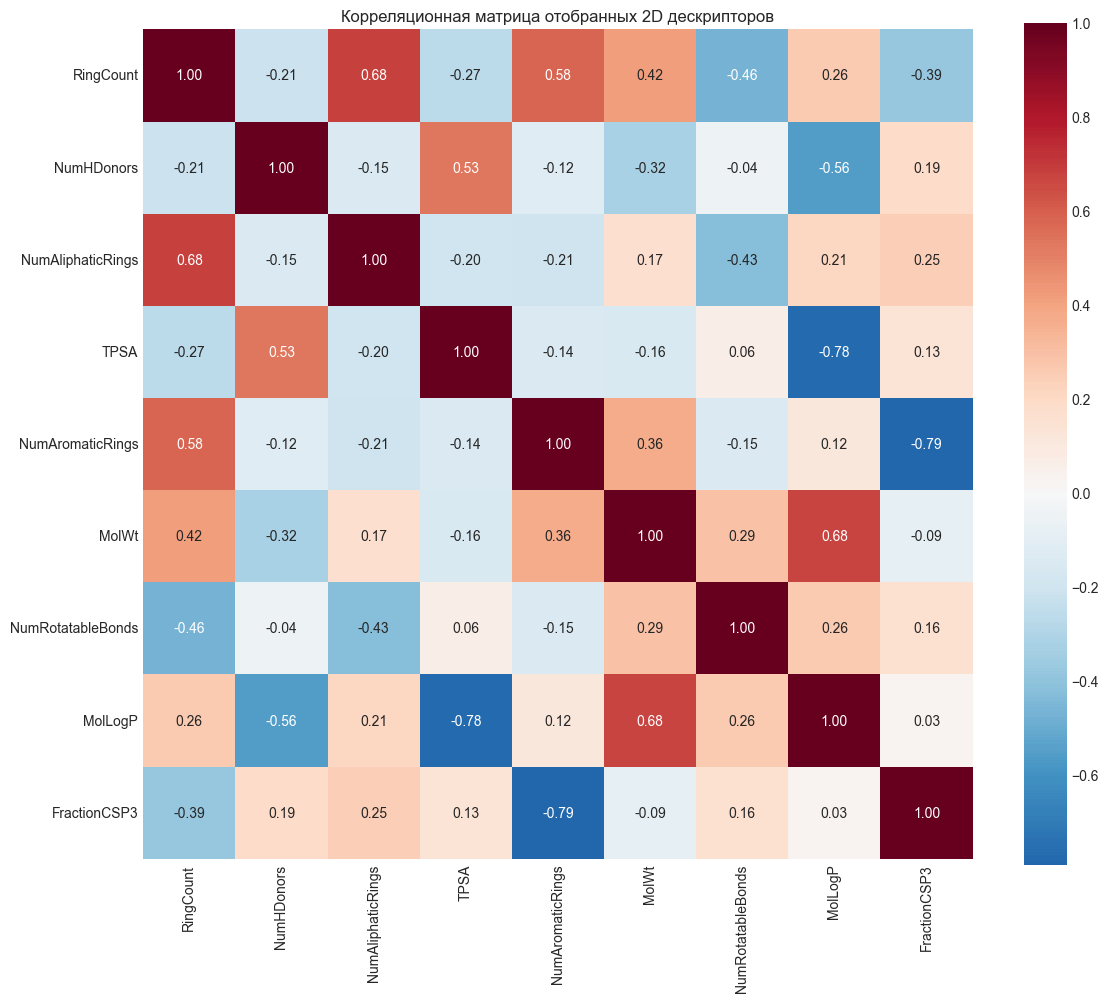

In [109]:
# Корреляционная матрица отобранных 2D дескрипторов
desc_2d_selected = [c for c in X_selected.columns if not c.startswith("morgan_")]
if len(desc_2d_selected) > 2:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        X_selected[desc_2d_selected].corr(),
        annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        square=True, ax=ax
    )
    ax.set_title("Корреляционная матрица отобранных 2D дескрипторов")
    plt.tight_layout()
    plt.show()

## 5. Обучение моделей

Сравним несколько подходов:
- **Linear Regression** (baseline)
- **Random Forest**
- **Gradient Boosting**
- **CatBoost**

### Задание 11: Разделение данных и функция оценки

1. Разделите данные на train/test (`train_test_split`, `test_size=0.2`, `random_state=42`)
2. Примените `StandardScaler` к train и test
3. Реализуйте функцию `evaluate_model(model, X_train, X_test, y_train, y_test, name)`,
   которая обучает модель, предсказывает и возвращает dict с MAE, RMSE, R2

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor


def evaluate_model(model, X_train, X_test, y_train, y_test, name: str) -> dict:
    # YOUR CODE HERE
    pass


# YOUR CODE HERE: train_test_split + StandardScaler



### Задание 12: Обучите и сравните модели

Создайте словарь моделей и обучите каждую:
- Linear Regression
- Ridge (alpha=1)
- Random Forest (n_estimators=200, max_depth=10)
- Gradient Boosting (n_estimators=200, learning_rate=0.1, max_depth=5)
- CatBoost (iterations=500, learning_rate=0.05, depth=6, verbose=0)

Учтите, что линейные модели требуют масштабирования (`X_train_scaled`), а деревья -- нет.

In [ ]:
# YOUR CODE HERE



### Задание 13: Визуализация результатов

Постройте 3 графика:
1. Барплот MAE по моделям
2. Барплот R2 по моделям
3. Scatter Predicted vs True RON для лучшей модели

In [ ]:
# YOUR CODE HERE



### Задание 14: Feature Importance

Выведите и визуализируйте top-20 признаков по важности (`feature_importances_`) для CatBoost.

In [ ]:
# YOUR CODE HERE



## 6. Логирование экспериментов с MLflow

**MLflow** позволяет:
- Отслеживать параметры, метрики и артефакты экспериментов
- Сравнивать разные запуски
- Воспроизводить результаты

```
# Запуск UI после выполнения ячеек:
# mlflow ui --backend-store-uri mlruns
```

In [ ]:
import mlflow
import mlflow.sklearn
import mlflow.catboost

# Настраиваем MLflow
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("RON_MON_prediction")

print("MLflow настроен. Experiment: RON_MON_prediction")

### Задание 15: Логирование в MLflow

Для каждой модели создайте `mlflow.start_run()` и залогируйте:
- Параметры: `mlflow.log_param("model_type", name)`, n_features, target
- Метрики: `mlflow.log_metric("mae", mae)`, rmse, r2
- Модель: `mlflow.sklearn.log_model(model, "model")` или `mlflow.catboost.log_model(model, "model")`

In [ ]:
# YOUR CODE HERE



## 7. Конфигурация пайплайна с Hydra

**Hydra** позволяет:
- Выносить все параметры в YAML-конфиги
- Запускать эксперименты с разными конфигурациями из CLI
- Делать multirun (sweep) по параметрам

Конфиг `configs/config.yaml` уже создан. Посмотрим, как его использовать:

In [ ]:
# Загрузка конфига Hydra в ноутбуке
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import os

config_dir = os.path.join(os.getcwd(), "configs")

with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))

In [ ]:
# Пример использования конфига
print(f"Target: {cfg.data.target}")
print(f"Test size: {cfg.data.test_size}")
print(f"Model: {cfg.model.name}")
print(f"CatBoost iterations: {cfg.model.catboost.iterations}")
print(f"Morgan radius: {cfg.descriptors.morgan_radius}")
print(f"Feature selection method: {cfg.feature_selection.method}")

print("\n--- Пайплайн можно запускать из CLI: ---")
print("python pipeline.py")
print("python pipeline.py data.target=MON model.name=random_forest")
print("python pipeline.py --multirun model.catboost.depth=4,6,8")

## 8. Подбор гиперпараметров с Optuna

**Optuna** -- фреймворк для автоматического подбора гиперпараметров:
- Алгоритм TPE (Tree-structured Parzen Estimator)
- Pruning неперспективных trial-ов
- Визуализация пространства поиска

### Задание 16: Optuna -- целевая функция

Реализуйте `objective(trial)` для оптимизации CatBoost:

Используйте `trial.suggest_*` для параметров:
- `iterations`: int, 100-1000
- `learning_rate`: float, 0.01-0.3, log scale
- `depth`: int, 3-10
- `l2_leaf_reg`: float, 0.01-10, log scale
- `min_data_in_leaf`: int, 1-30

Оцените через `cross_val_score` с `scoring="neg_mean_absolute_error"` и верните `-scores.mean()`.

Создайте study и запустите `study.optimize(objective, n_trials=30, timeout=120)`.

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # YOUR CODE HERE
    pass


# YOUR CODE HERE: create study and optimize



In [ ]:
# Визуализация результатов Optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# История оптимизации
plot_optimization_history(study, ax=axes[0])
axes[0].set_title("История оптимизации")

# Важность гиперпараметров
plot_param_importances(study, ax=axes[1])
axes[1].set_title("Важность гиперпараметров")

plt.tight_layout()
plt.show()

### Задание 17: Финальная модель

1. Обучите CatBoost с лучшими параметрами из `study.best_params`
2. Выведите MAE, RMSE, R2 на тестовой выборке
3. Залогируйте результат в MLflow (run_name="CatBoost_Optuna_best")

In [ ]:
# YOUR CODE HERE



### Задание 18: Финальная визуализация

Постройте два графика:
1. Predicted vs True RON для лучшей модели
2. Анализ остатков (residuals vs predicted)

In [ ]:
# YOUR CODE HERE



## 9. Итоговый пайплайн

Файл `pipeline.py` объединяет все шаги в единый пайплайн с Hydra-конфигурацией:

```bash
# Базовый запуск
python pipeline.py

# Предсказание MON вместо RON
python pipeline.py data.target=MON

# Другая модель
python pipeline.py model.name=random_forest

# Sweep по гиперпараметрам
python pipeline.py --multirun model.catboost.depth=4,6,8 model.catboost.learning_rate=0.01,0.05,0.1

# Просмотр результатов в MLflow
mlflow ui --backend-store-uri mlruns
```

### Что мы изучили:

1. **RDKit** -- вычисление 2D дескрипторов, Morgan/MACCS fingerprints
2. **Feature Selection** -- VarianceThreshold, корреляционный фильтр, Mutual Information
3. **Модели** -- от линейных до gradient boosting (CatBoost)
4. **MLflow** -- логирование параметров, метрик, моделей
5. **Hydra** -- управление конфигурацией пайплайна
6. **Optuna** -- автоматический подбор гиперпараметров

### Задания для самостоятельной работы

1. Обучите модель для предсказания **MON** вместо RON. Сравните качество.
2. Добавьте **MACCS fingerprints** к признакам и оцените влияние на качество.
3. Попробуйте использовать только **структурные дескрипторы из датасета** (P, S, T, ...) без RDKit-дескрипторов.
4. Реализуйте **кросс-валидацию с группами** (GroupKFold по FuelClass) -- как изменится качество?
5. Настройте Optuna для оптимизации **одновременно RON и MON** (multi-objective).